# CoverForge AI

## Generación de portadas de libros mediante Inteligencia Artificial

**Proyecto Final — Generación de Prompts**

CoverForge AI es una propuesta de aplicación basada en Inteligencia Artificial que permite generar portadas de libros a partir de información básica proporcionada por el usuario.

El proyecto utiliza un modelo de lenguaje para transformar los datos del libro en un prompt detallado y optimizado para un generador de imágenes.



In [ ]:
!pip install -q groq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.8/143.8 kB 2.9 MB/s eta 0:00:00


In [ ]:
import os

try:
    from google.colab import userdata
    os.environ['GROQ_API_KEY'] = userdata.get('GROQ_API_KEY')
    print('Key cargada desde Colab Secrets')
except Exception:
    assert os.environ.get('GROQ_API_KEY'), 'Falta definir la variable de entorno GROQ_API_KEY'
    print('Key cargada desde variable de entorno')

from groq import Groq

MODELO = 'openai/gpt-oss-20b'

client = Groq(api_key=os.environ.get('GROQ_API_KEY'))


def chat(user, system='Sos un asistente claro y conciso que responde en español.',
         modelo=None, temperature=0.7):
    """Envía un prompt y devuelve el texto de la respuesta.

    system -> define CÓMO responde el modelo · user -> QUÉ se le pide.
    """
    r = client.chat.completions.create(
        model=modelo or MODELO,
        messages=[
            {'role': 'system', 'content': system},
            {'role': 'user', 'content': user},
        ],
        temperature=temperature,
    )
    return r.choices[0].message.content


print('Listo. Cliente de Groq configurado con', MODELO)

Key cargada desde Colab Secrets
Listo. Cliente de Groq configurado con openai/gpt-oss-20b


In [ ]:
titulo = "El reino de las sombras"
autor = "Felipe Signorelli"
genero = "Fantasía épica"
descripcion = """
Un joven descubre una antigua ciudad perdida debajo de un reino en guerra.
Allí encuentra un poder olvidado que puede cambiar el destino de todo el mundo.
"""
estilo = "Oscuro, épico y misterioso"

In [ ]:
prompt_portada = f"""
Sos un experto en diseño editorial y generación de prompts para portadas de libros.

Tu tarea es crear un prompt detallado para generar la portada de un libro.

DATOS DEL LIBRO:

Título: {titulo}
Autor: {autor}
Género: {genero}
Descripción: {descripcion}
Estilo visual: {estilo}

El prompt generado debe describir:

- La composición de la portada.
- El escenario y los elementos principales.
- La atmósfera y el estado de ánimo.
- La iluminación.
- La paleta de colores.
- El estilo artístico.
- La ubicación del título y del nombre del autor.
- Una composición vertical adecuada para una portada de libro.

No inventes información que contradiga los datos proporcionados.

Devolvé únicamente el prompt final, listo para utilizar en un generador de imágenes.
"""

prompt_generado = chat(
    prompt_portada,
    system="Sos un especialista en diseño de portadas y Prompt Engineering. Respondé en español.",
    temperature=0.8
)

print(prompt_generado)

**Prompt para generar la portada del libro “El reino de las sombras”**

```
Create a vertical (portrait) fantasy epic book cover in a dark, epic, and mysterious style. Center a young protagonist in the foreground, standing on a stone ledge overlooking a vast, ancient underground city. The city should feature towering, crumbling spires, archways, and intricate stonework, all shrouded in mist and shadow. Behind the city, a faint silhouette of a war‑torn kingdom can be seen, with distant smoke and a hint of a looming battle. The young hero holds a glowing, forgotten relic (a crystal or rune‑etched staff) that emits a soft, ethereal blue light, illuminating his face and the immediate surroundings. 

Atmosphere & Mood: moody, tense, and awe‑inspiring. Use deep shadows and contrasting highlights to emphasize the hidden power and the looming threat. The overall feeling should be one of discovery and impending destiny.

Lighting: dramatic, with a main source of light coming from the relic, cas

In [ ]:
#imagen generada en : https://www.craiyon.com/en/image/4Xlj9xtDQ-mYd2ElHENh9g

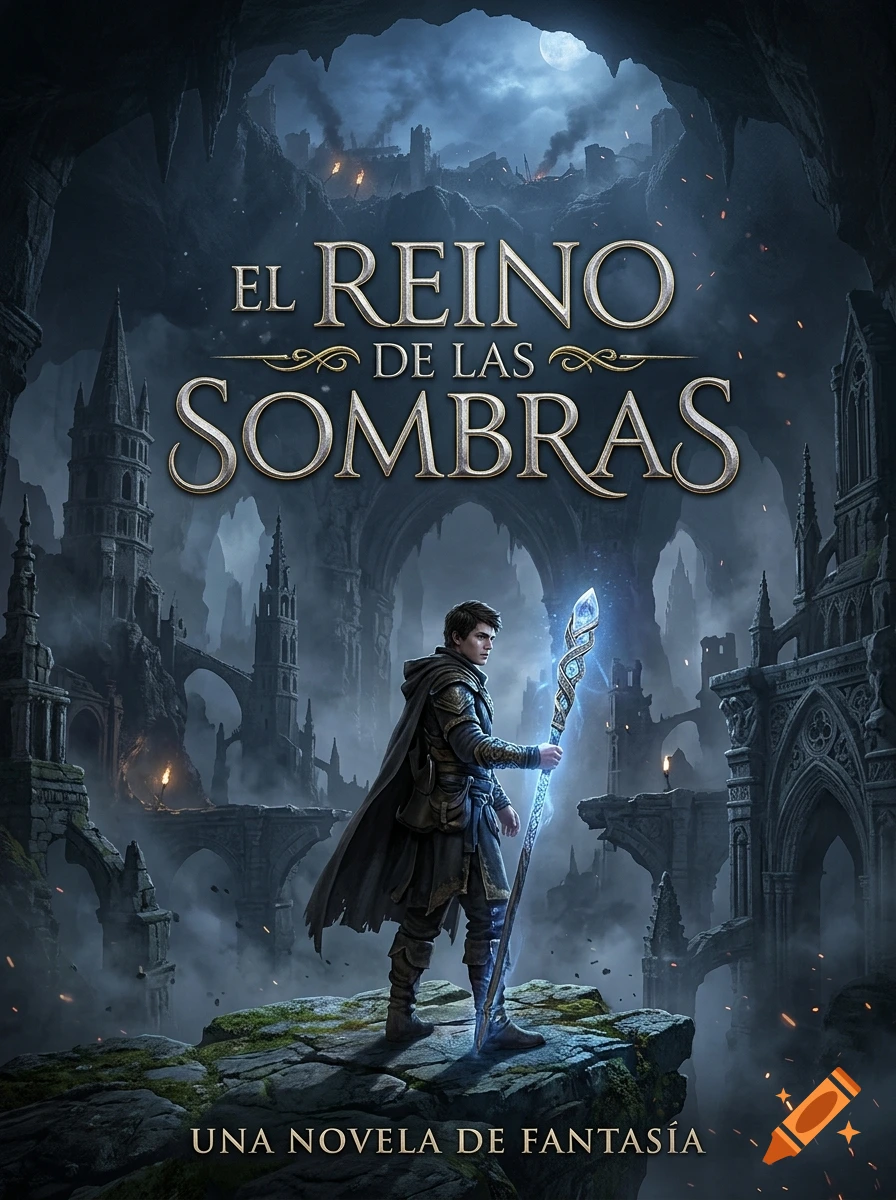